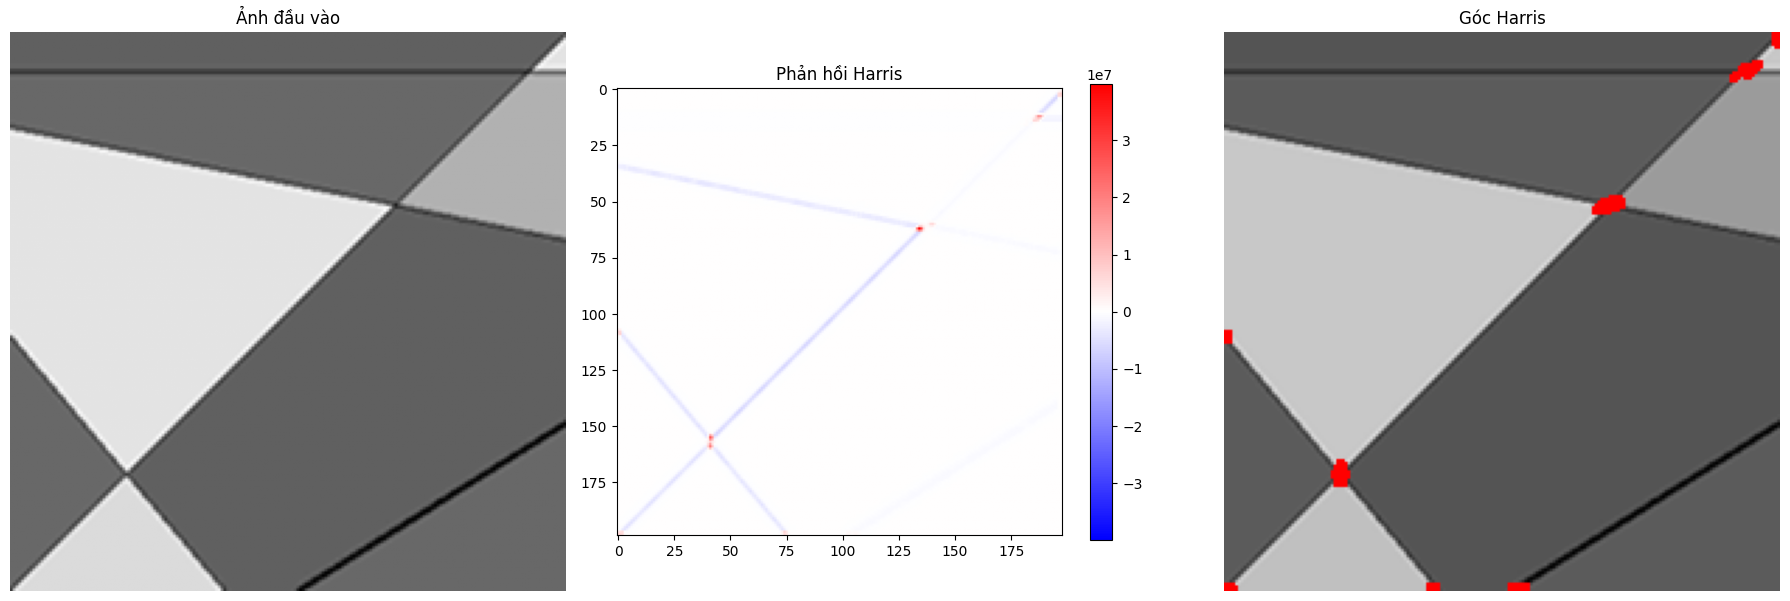

Kích thước ảnh đầu vào: (199, 198, 3)
Kích thước ảnh xám: (199, 198)
Giá trị phản hồi Harris nhỏ nhất: -6505431.0
Giá trị phản hồi Harris lớn nhất: 39923340.0
Ngưỡng phát hiện góc: 399233.4
Số điểm ảnh được đánh dấu là góc: 259


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN GÓC HARRIS
# Chương/Mục liên quan: Chương 5 - Điểm đặc trưng và phát hiện góc
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán phát hiện góc bằng thuật toán Harris.
# - Giúp người học quan sát trực tiếp phản hồi Harris trên ảnh đầu vào.
# - Liên hệ phần code với thuật toán phát hiện điểm góc trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách ảnh màu được chuyển sang ảnh xám trước khi phát hiện góc.
# 2. Quan sát được bản đồ phản hồi Harris.
# 3. Nhận biết được các điểm có phản hồi lớn được đánh dấu là góc.

# Input:
# - Dữ liệu đầu vào: ảnh từ GitHub
# - Kiểu dữ liệu: ảnh màu, sau đó chuyển sang ảnh xám

# Output:
# - Ảnh đầu vào dạng xám
# - Bản đồ phản hồi Harris
# - Ảnh kết quả với các góc Harris được đánh dấu màu đỏ

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_COLOR)

image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/lines.png"

I = read_gitlab_image(image_uri)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

I_gray = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)
I_gray_f = np.float32(I_gray)

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Tính phản hồi Harris.
# Dòng code này tương ứng với bước tính hàm phản hồi góc Harris R trong lý thuyết.
R = cv2.cornerHarris(I_gray_f, blockSize=3, ksize=3, k=0.04)

# Làm giãn bản đồ phản hồi để các điểm góc dễ quan sát hơn khi hiển thị.
R_dilated = cv2.dilate(R, None)

# Ngưỡng phát hiện góc.
threshold = 0.01 * R_dilated.max()

# Chỉ giữ đáp ứng góc dương để hiển thị đẹp hơn.
R_pos = np.maximum(R, 0)
R_vis_pos = np.log1p(R_pos)

# Chỉ giữ đáp ứng góc âm để hiển thị độ lớn.
R_neg = np.minimum(R, 0)
R_vis_neg = np.log1p(np.abs(R_neg))

# Tạo ảnh kết quả và đánh dấu các điểm góc bằng màu đỏ.
I_corner = cv2.cvtColor(I_gray, cv2.COLOR_GRAY2RGB)
I_corner[R_dilated > threshold] = [255, 0, 0]

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh đầu vào")
plt.axis("off")

plt.subplot(1, 3, 2)
abs_max_R = np.max(np.abs(R))
plt.imshow(R, cmap="bwr", vmin=-abs_max_R, vmax=abs_max_R)
plt.title("Phản hồi Harris")
plt.axis("on")
plt.colorbar(shrink=0.8)

plt.subplot(1, 3, 3)
plt.imshow(I_corner)
plt.title("Góc Harris")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

num_corners = np.sum(R_dilated > threshold)

print("Kích thước ảnh đầu vào:", I.shape)
print("Kích thước ảnh xám:", I_gray.shape)
print("Giá trị phản hồi Harris nhỏ nhất:", R.min())
print("Giá trị phản hồi Harris lớn nhất:", R.max())
print("Ngưỡng phát hiện góc:", threshold)
print("Số điểm ảnh được đánh dấu là góc:", num_corners)

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi blockSize trong cv2.cornerHarris, ví dụ: blockSize=2, 3, 5.
# 2. Thay đổi ksize trong cv2.cornerHarris, ví dụ: ksize=3, 5, 7.
# 3. Thay đổi hệ số ngưỡng, ví dụ: threshold = 0.005 * R_dilated.max()
#    hoặc threshold = 0.02 * R_dilated.max().